# Lecture 5 - Experimental Design, Cross-validation Schemes & The Curse of Dimensionality

---

# Strategies to Mitigate Overfitting

1. Add more data! - when possible

2. Occam's Razor - select a model with lower complexity

3. Regularization - constrains/regularizes the coefficients of the model

4. Cross-validation - technique for utilizing the training data to fine-tune hyperparameter values

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

In [2]:
def NoisySinusoidalData(N, a, b, sigma):
    '''Generates N data points in the range [a,b) sampled from a sin(2*pi*x) 
    with additive zero-mean Gaussian random noise with standard deviation sigma'''

    # Fixing random seed for reproducibility
    np.random.seed(42)
    
    # N input samples, evenly spaced numbers between [a,b) incrementing by 1/N
    x = np.linspace(a,b,N)
    
    # draw N sampled from a univariate Gaussian distribution with mean 0, sigma standard deviation and N data points
    noise = np.random.normal(0,sigma,N,)
    
    # desired values, noisy sinusoidal
    t = np.sin(2*np.pi*x) + noise
    
    return x, t

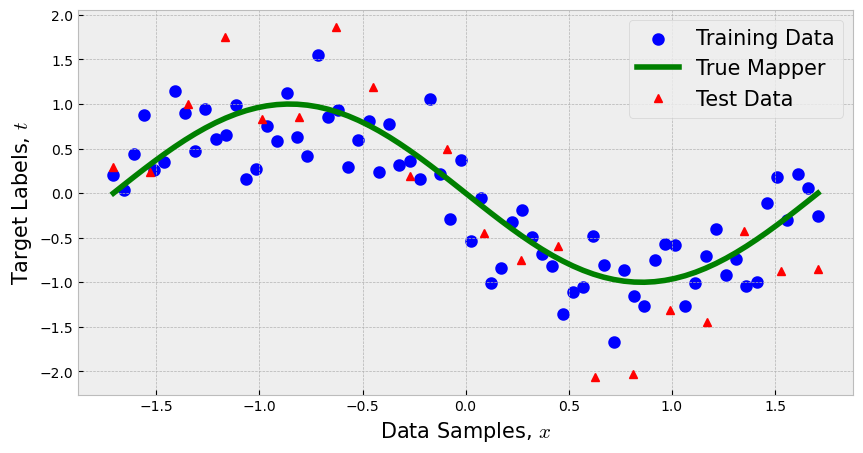

In [3]:
from sklearn.preprocessing import StandardScaler

# Generate input samples and desired values
N_train = 70 # number of data samples for training
N_test = 20 # number of data samples for test

a, b = [0,1] # data samples interval

sigma_train = 0.4 # standard deviation of the zero-mean Gaussian noise -- training data
sigma_test = 0.6 # standard deviation of the zero-mean Gaussian noise -- test data

x_train, t_train = NoisySinusoidalData(N_train, a, b, sigma_train) # Training Data - Noisy sinusoidal
x_true, t_true = NoisySinusoidalData(N_train, a, b, 0) # True Sinusoidal - in practice, we don't have the true fct
x_test, t_test = NoisySinusoidalData(N_test, a, b, sigma_test) # Test Data - Noisy sinusoidal

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train[:,np.newaxis]).ravel()
x_test = scaler.transform(x_test[:,np.newaxis]).ravel()
x_true = scaler.transform(x_true[:,np.newaxis]).ravel()

plt.figure(figsize=(10,5))
plt.scatter(x_train, t_train, c='b', linewidths=3, label = 'Training Data')
plt.plot(x_true, t_true, 'g', linewidth=4, label = 'True Mapper')
plt.plot(x_test, t_test, 'r^', label = 'Test Data')
plt.legend(fontsize=15)
plt.xlabel('Data Samples, $x$',size=15)
plt.ylabel('Target Labels, $t$',size=15);

In [4]:
def PolynomialRegression(x,t,M):
    '''Fit a polynomial of order M to the data input data x and desire values t.
    MSE objective function.'''
    
    # Compute feature matrix X with polynomial features
    X = np.array([x**i for i in range(M+1)]).T # this creates an N-by-(M+1) matrix
    
    # Compute the solution for the parameters w, using the MSE ojective function
    w = np.linalg.inv(X.T@X)@X.T@t 
    
    # Compute model prediction
    y = X@w
    
    return w, y

def PolynomialRegression_test(x_test, w):
    '''Use a trained linear regression model with polynomial features for inference.'''
    # Compute test feature matrix
    X_test = np.array([x_test**i for i in range(len(w))]).T # this is a N_test-by-(M+1) matrix
    
    # Prediction for test samples using the trained model
    y_test = X_test@w
    
    return y_test

def PolynomialRegression_reg(x,t,M,lam):
    '''Fit a polynomial of order M to the data input data x and desire values t. 
    MSE objective function with the Ridge regularizer.'''
    
    # Compute feature matrix X with polynomial features
    X = np.array([x**i for i in range(M+1)]).T # this creates an N-by-(M+1) matrix
    
    # Compute the solution for the parameters w, using the MSE ojective function
    w = np.linalg.inv(X.T@X + lam*np.eye(M+1))@X.T@t 
    
    # Compute model prediction
    y = X@w
    
    return w, y

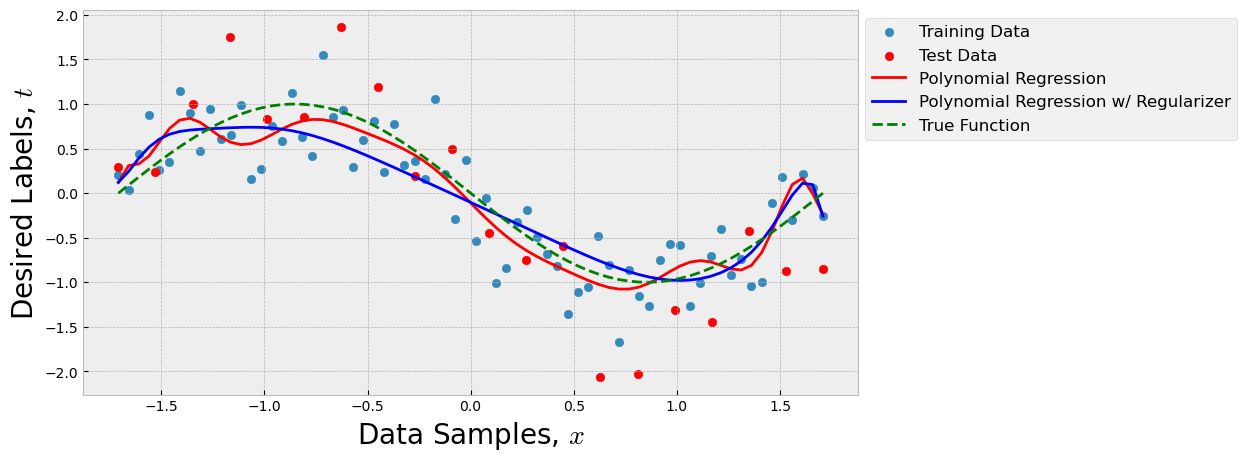

In [5]:
M = 15
lam = 2

w, y = PolynomialRegression(x_train,t_train,M) 
w_reg, y_reg = PolynomialRegression_reg(x_train,t_train,M,lam) 

fig=plt.figure(figsize=(10,5))
plt.scatter(x_train,t_train, label='Training Data')
plt.scatter(x_test,t_test, c='r', label='Test Data')
plt.plot(x_train,y,'r', label = 'Polynomial Regression')
plt.plot(x_train,y_reg, 'b',label = 'Polynomial Regression w/ Regularizer')
plt.plot(x_true,t_true,'--g', label = 'True Function')
plt.legend(bbox_to_anchor=(1.5, 1),fontsize=12,ncol=1)
plt.xlabel('Data Samples, $x$', fontsize=20)
plt.ylabel('Desired Labels, $t$', fontsize=20);

# Performance Measures for Regression Tasks

In order to determine if the model is able to **generalize** to a **validation set**, we need to determine a **performance measure**.

Which measures would you use to compare model performances?

1. Error measures are always a good start for **regression** tasks. Some examples include:

    * Mean Squared Error (MSE) - best when the data does not have outliers. The MSE will penalize outliers heavily.

    * Mean Absolute Error (MAE) - best when you suspect data has outliers.
    
    * Normalized mean squared error (NMSE).
    
    * Normalized mean absolute error (NMAE).

2. Coefficient of Determination $r^2$
    * Advantage: it is bounded between $[0,1]$, where values closer to 1 indicate a better prediction.
    
3. Quantile-Quantile plot (or Q-Q plot)

    * Qualitative measurement of the model predictions vs the target values.
    * The Q-Q plot is used to answer the following questions:
        * Do two data sets come from populations with a common distribution?
        * Do two data sets have common location and scale?
        * Do two data sets have similar distributional shapes?
        * Do two data sets have similar tail behavior?

In [6]:
## Predictions in training/test sets with and without regularization
y = PolynomialRegression_test(x_train, w)
y_test = PolynomialRegression_test(x_test, w)

y_reg = PolynomialRegression_test(x_train, w_reg)
y_test_reg = PolynomialRegression_test(x_test, w_reg)

## Error Measures
# Residual error for Training data for polynomial regression without and with regularizer
error_train = t_train - y 
error_train_reg = t_train - y_reg 

# Residual error for Test data for polynomial regression without and with regularizer
error_test = t_test - y_test
error_test_reg = t_test - y_test_reg

# Error Measures
print('Mean Squared Error \n')
print('Training Set')
print('Without regularizer: ', np.mean(error_train**2))
print('With regularizer: ', np.mean(error_train_reg**2),'\n')
print('Test Set')
print('Without regularizer: ', np.mean(error_test**2))
print('With regularizer: ', np.mean(error_test_reg**2),'\n')
print('----------------------------------------------------------------')
print('Mean Absolute Error \n')
print('Training Set')
print('Without regularizer: ', np.mean(np.abs(error_train)))
print('With regularizer: ', np.mean(np.abs(error_train_reg)),'\n')
print('Test Set')
print('Without regularizer: ', np.mean(np.abs(error_test)))
print('With regularizer: ', np.mean(np.abs(error_test_reg)),'\n')

Mean Squared Error 

Training Set
Without regularizer:  0.09927043634520141
With regularizer:  0.12894251548077149 

Test Set
Without regularizer:  0.36282431622746925
With regularizer:  0.423004972462368 

----------------------------------------------------------------
Mean Absolute Error 

Training Set
Without regularizer:  0.263595936675582
With regularizer:  0.2839971490402194 

Test Set
Without regularizer:  0.48984370556677626
With regularizer:  0.5113613777430893 



In [7]:
## R2-SCORE - coefficient of determination

# it measures how much variance in one variance is explained by another variable 

from sklearn.metrics import r2_score

print('Test set without regularization:', r2_score(t_test, y_test))

print('Test set with regularization:', r2_score(t_test, y_test_reg))

Test set without regularization: 0.7161038177697114
Test set with regularization: 0.6690147507335047


The coefficient of determination $r^2$ is bounded between $[0,1]$. The closer to 1, the closer the predictions are to the target value.

In [8]:
## QUANTILES

np.quantile(y, 0.5), np.median(y) #, np.mean(y)

# median

(0.08015506559222224, 0.08015506559222224)

In [9]:
np.quantile(y, 0), np.min(y)

# minimum

(-1.076338966299511, -1.076338966299511)

In [10]:
np.quantile(y, 1), np.max(y)

# maximum

(0.8394412929669056, 0.8394412929669056)

In [11]:
np.linspace(0,1,10)

array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])

In [12]:
np.quantile(y, np.linspace(0,1,10))

array([-1.07633897, -0.93538563, -0.80969823, -0.64607063, -0.15132625,
        0.20331689,  0.54479529,  0.63884559,  0.77173963,  0.83944129])

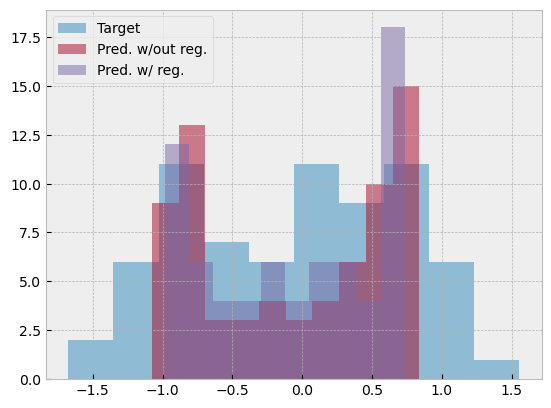

In [13]:
plt.hist(t_train, alpha=0.5, label='Target')
plt.hist(y, alpha=0.5, label='Pred. w/out reg.')
plt.hist(y_reg, alpha=0.5, label='Pred. w/ reg.')
plt.legend();

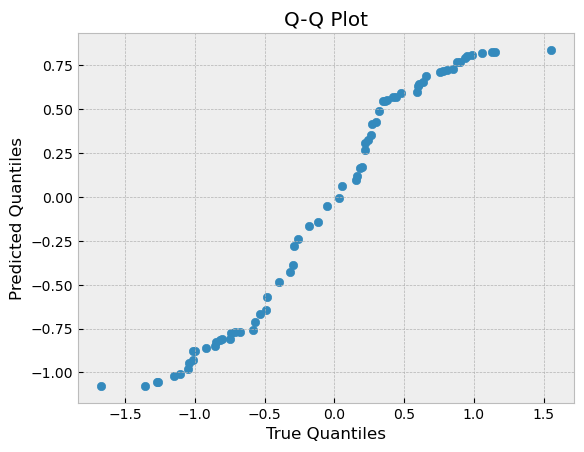

In [14]:
plt.scatter(np.quantile(t_train, np.linspace(0,1,len(t_train))), 
           np.quantile(y, np.linspace(0,1,len(t_train))))
plt.xlabel('True Quantiles')
plt.ylabel('Predicted Quantiles')
plt.title('Q-Q Plot');

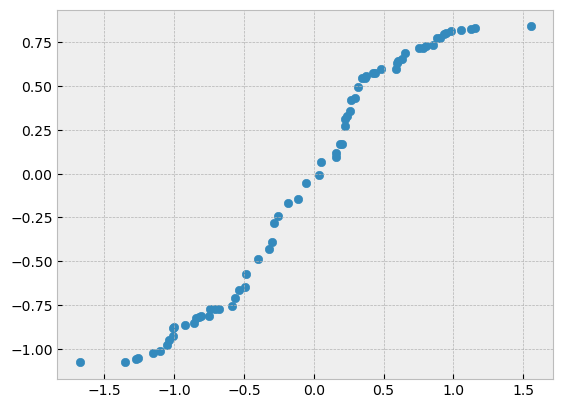

In [15]:
# alternative way to plot the Q-Q plot

plt.scatter(np.sort(t_train), np.sort(y));

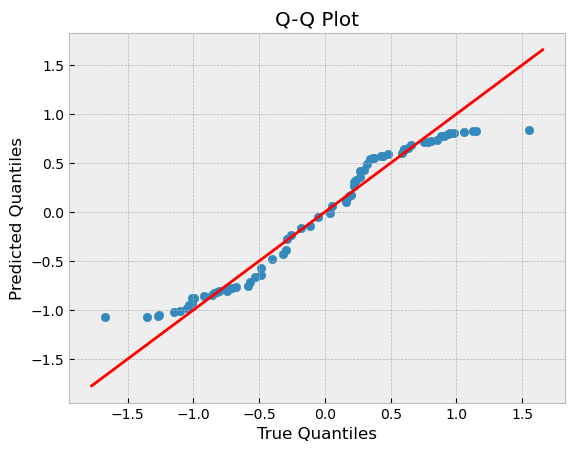

In [16]:
base = np.linspace(min(t_train)-0.1,max(t_train)+0.1,100)
plt.plot(base,base,'r')
plt.scatter(np.sort(t_train), np.sort(y))
plt.xlabel('True Quantiles')
plt.ylabel('Predicted Quantiles')
plt.title('Q-Q Plot');

In [17]:
print('R2 Score for Training without regularizer:', r2_score(np.sort(t_train), np.sort(y)))

print('R2 Score for Test without regularizer:', r2_score(np.sort(t_test), np.sort(y_test)))

R2 Score for Training without regularizer: 0.951826963889152
R2 Score for Test without regularizer: 0.7939864348423977


In [18]:
print('R2 Score for Training with regularizer:', r2_score(np.sort(t_train), np.sort(y_reg)))

print('R2 Score for Test with regularizer:', r2_score(np.sort(t_test), np.sort(y_test_reg)))

R2 Score for Training with regularizer: 0.9365956093159628
R2 Score for Test with regularizer: 0.7512121340203461


In practice, we consider a good fit if the $r^2$ of the Q-Q plot if **greater than 0.9**, ideally >0.99.

## Other Performance Measures

Performance of an algorithm can be determined using a variety of statistical goodness-of-fit measures. 

* For regression tasks this includes error-based measurements, hypothesis tests, Q-Q plots.
* For classification tasks this includes error rate, accuracy, ROC curves, performance-recall curves.

But it can also be in terms of:
1. Risk,
2. Training time,
3. Training storage/memory,
4. Testing time,
5. Testing storage/memory,
6. Interpretability, namely, whether the method allows knowledge extraction which can be checked and validated by experts, and
7. computational complexity.

---

# Strategies to Mitigate Overfitting

1. Add more data! - when possible

2. Occam's Razor - select a model with lower complexity

3. Regularization - constrains/regularizes the coefficients of the model

4. Cross-validation - technique for utilizing the training data to fine-tune hyperparameter values

---

# Cross-Validation

The goal of **cross-validation**, or CV, is to test the model's ability to predict new data that was not used in estimating the model, in order to flag problems like overfitting or selection bias and to give an insight on how the model will generalize to an independent dataset (i.e., an unknown dataset).

Cross-validation allows us to determine the values for the hyperparameter that provide the most **generalization**. Cross-validation mitigates the occurrrence of overfitting, but it does not eliminate it entirely.

Suggested reading: 

* [Sections 19.1-19.6](https://ufl.instructure.com/courses/455013/external_tools/412362?display=borderless) from the Alpaydin textbook 
* [Section 5.3 Hyperparameters and Model Validation](https://jakevdp.github.io/PythonDataScienceHandbook/05.03-hyperparameters-and-model-validation.html) from the "Python Data Science Handbook" textbook.

## Strategies of Experimentation - Fine-Tuning Hyperparameters

To fully test a system, you want to try to evaluate each of these parameters separately. However, this is often not easily done.

A few strategies for fine-tuning hyperparameters include:

* Best guess
* One factor at a time
* Factorial design or **grid search**
* Randomized search

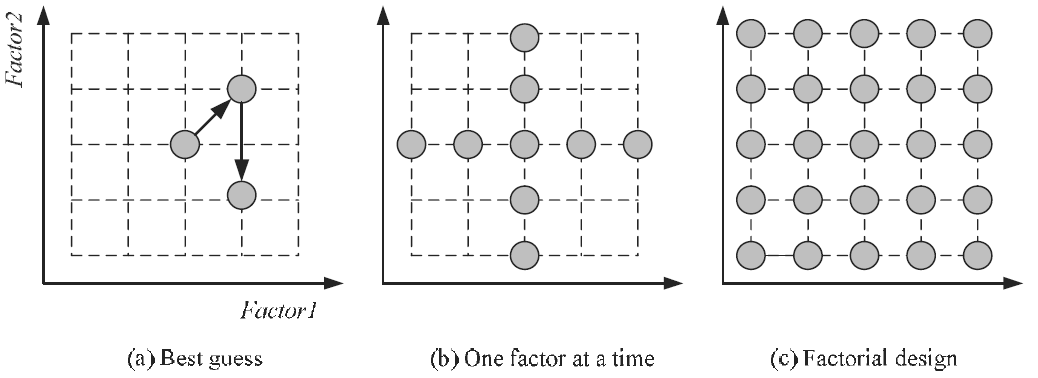

In [19]:
from IPython.display import Image
Image('figures/Experimentation.png',width=800)
# Source: Alpaydin, E. (2014) Introduction to Machine Learning. 3rd edition, MIT Press.

We first must select a **performance measure**, e.g. mean square error (MSE), coefficient of determination $r^2$. There are different strategies for implementing cross-validation:

1. $k\times 2$ cross-validation
2. k-fold cross-validation
3. Leave-One-Out cross-validation
4. Stratified cross-validation

We also need to make sure that classes are represented in the right proportions when subsets of data are held out, not to disturb the class prior probabilities; this is called **stratiﬁcation**. If a class has 20 percent examples in the whole dataset, in all samples drawn from the dataset, it should also have approximately 20 percent examples.

## $1\times 2$ cross-validation

Let's consider the case, where we only have a single validation set which resulted from splitting the training data into a training set and a validation set with splitting rations 70% and 30% respectively.

In [20]:
from sklearn.model_selection import train_test_split

x_train2, x_validation, t_train2, t_validation = train_test_split(x_train, t_train, 
                                                                  test_size=0.3,
                                                                  shuffle=True,
                                                                 random_state=0)

x_train2.shape, x_validation.shape, t_train2.shape, t_validation.shape

((49,), (21,), (49,), (21,))

Let's now vary the values for $M$ and estimate the associated coefficients $\mathbf{w}$ using the training set. Then, let's evaluate performance measure (e.g. MSE) in both training and validation sets:

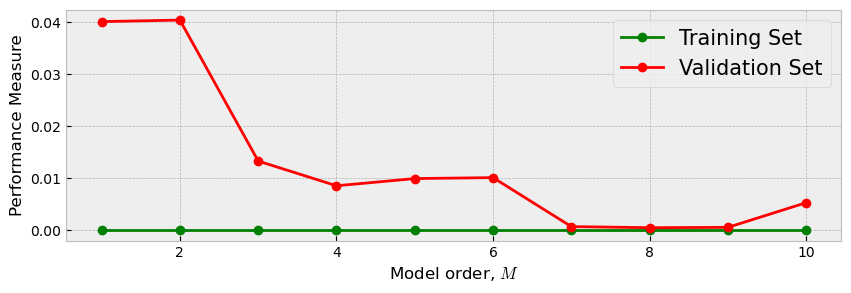

In [21]:
# Range of values for M - Polynomial Regression WITHOUT regularizer
M_vals = range(1,11)

perf_train = []
perf_val = []
for M in M_vals:
    
    # Train the model (without regularization for simplicity of illustration)
    w, y_train = PolynomialRegression(x_train2, t_train2, M)
    
    # Make predictions for the training and validation sets
    y_validation = PolynomialRegression_test(x_validation, w)
    
    # Performance Measure - MSE
    perf_train += [np.mean(t_train2-y_train)**2]
    perf_val += [np.mean(t_validation-y_validation)**2]
    
# Plotting results
plt.figure(figsize=(10,3))
plt.plot(M_vals, perf_train, '-og',label='Training Set')
plt.plot(M_vals, perf_val, '-or',label='Validation Set')
plt.legend(fontsize=15)
plt.xlabel('Model order, $M$', size=12)
plt.ylabel('Performance Measure', size=12);

## K-Fold Cross-Validation

The technique of k-fold cross-validation, illustrated below for the case of $k=4$, involves taking the available data and partitioning it into $k$ groups (in the simplest case these are of equal size). Then $k-1$ of the groups are used to train a set of models that are then evaluated on the remaining group. This procedure is then repeated for all $k$ possible choices for the held-out group, indicated in the picture below by the red blocks, and the performance scores from the runs are then averaged.

$K$ is typically 10 or 30. As $K$ increases, the percentage of training instances increases and we get more robust estimators, but the validation set becomes smaller. Furthermore, there is the cost of training the classiﬁer $K$ times, which increases as $K$ is increased. As $N$ increases, $K$ can be smaller; if $N$ is small, $K$ should be large to allow large enough training sets.

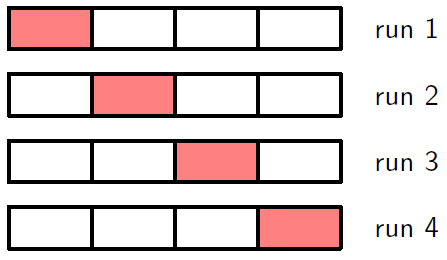

In [22]:
Image('figures/Kfold CV.png',width=400)

In [23]:
from sklearn.model_selection import KFold

KFold?

Init signature: KFold(n_splits=5, *, shuffle=False, random_state=None)
Docstring:     
K-Fold cross-validator.

Provides train/test indices to split data in train/test sets. Split
dataset into k consecutive folds (without shuffling by default).

Each fold is then used once as a validation while the k - 1 remaining
folds form the training set.

Read more in the :ref:`User Guide <k_fold>`.

For visualisation of cross-validation behaviour and
comparison between common scikit-learn split methods
refer to :ref:`sphx_glr_auto_examples_model_selection_plot_cv_indices.py`

Parameters
----------
n_splits : int, default=5
    Number of folds. Must be at least 2.

    .. versionchanged:: 0.22
        ``n_splits`` default value changed from 3 to 5.

shuffle : bool, default=False
    Whether to shuffle the data before splitting into batches.
    Note that the samples within each split will not be shuffled.

random_state : int, RandomState instance or None, default=None
    When `shuffle` is True, `

**Goal:** find the best value for the **hyperparameters** $M$ (model order) and $\lambda$ (regularization trade-off parameter).

Let's use **4-fold cross-validation** on this data:

In [24]:
k = 4 # number of folds

kf = KFold(n_splits=k,shuffle=True, random_state=0)
kf

KFold(n_splits=4, random_state=0, shuffle=True)

In [25]:
kf.split(x_train)

<generator object _BaseKFold.split at 0x15a621690>

In [26]:
# Split training feature matrix into training and validation sets

f=1
for train_index, validation_index in kf.split(x_train):
    print('Fold ', f)
    print('The training set has ', train_index.shape[0],' samples')
    print('Their index locations are: ', train_index)
    print('The validation set has ', validation_index.shape[0],' samples')
    print('Their index locations are: ', validation_index,'\n')
    f+=1

Fold  1
The training set has  52  samples
Their index locations are:  [ 0  1  2  3  4  5  6  8  9 10 11 12 13 14 15 16 17 18 19 20 21 23 24 25
 29 32 35 36 37 38 39 40 41 43 44 45 46 47 49 50 52 53 54 57 58 60 61 63
 64 65 66 67]
The validation set has  18  samples
Their index locations are:  [ 7 22 26 27 28 30 31 33 34 42 48 51 55 56 59 62 68 69] 

Fold  2
The training set has  52  samples
Their index locations are:  [ 0  1  5  6  7  8  9 12 13 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29
 30 31 33 34 35 36 37 38 39 42 44 46 47 48 51 52 55 56 58 59 60 61 62 63
 64 66 68 69]
The validation set has  18  samples
Their index locations are:  [ 2  3  4 10 11 14 32 40 41 43 45 49 50 53 54 57 65 67] 

Fold  3
The training set has  53  samples
Their index locations are:  [ 1  2  3  4  6  7  9 10 11 12 14 21 22 23 24 26 27 28 30 31 32 33 34 36
 38 39 40 41 42 43 44 45 46 47 48 49 50 51 53 54 55 56 57 58 59 61 62 63
 64 65 67 68 69]
The validation set has  17  samples
Their index locations are: 

In [27]:
from sklearn.metrics import r2_score

# Set of values for lambda to explore - Polynomial Regression WITH REGULARIZER
M_vals = np.array(range(2,11))
lam_vals= np.arange(0.01,1.1,0.01)

avg_train = np.zeros((len(M_vals), len(lam_vals)))
avg_valid   = np.zeros((len(M_vals), len(lam_vals)))

for i in range(len(M_vals)):
    for j in range(len(lam_vals)):
    
        M   = M_vals[i]
        lam = lam_vals[j]
        print('M Value = ',M)
        print('Lambda Value = ',lam)
    
        # For each training/validation split
        f=1
    
        #initialize performance measures
        perf_train_avg, perf_val_avg = 0, 0
    
        for train_index, validation_index in kf.split(x_train):
            print('\nFold ',f)
    
            # Select training set using the indices found from kf.split
            x_train2, x_validation = x_train[train_index], x_train[validation_index]
    
            # Select validation set using the indices found from kf.split
            t_train2, t_validation = t_train[train_index], t_train[validation_index]
    
            # Training model with training set
            w, y_train = PolynomialRegression_reg(x_train2, t_train2, M, lam)
    
            # Evaluate trained model in validation set
            y_val = PolynomialRegression_test(x_validation, w)
    
            # Performance Measure - coefficient of determination 
            perf_train = r2_score(t_train2,y_train) #np.mean((t_train2-y_train)**2)
            perf_val   = r2_score(t_validation, y_val) #np.mean((t_validation-y_val)**2)
    
            # Average performance measure
            perf_train_avg = perf_train_avg + perf_train
            perf_val_avg = perf_val_avg + perf_val
            print('Performance Training = ', perf_train)
            print('Performance Validation = ', perf_val)
            f+=1

        # Average Performance
        avg_train[i,j] = perf_train_avg/k
        avg_valid[i,j] = perf_val_avg/k

        print('\nAverage Performance in Training = ', avg_train[i,j])
        print('Average Performance in Validation = ', avg_valid[i,j])
        print('-----------------------------------------------------\n')

M Value =  2
Lambda Value =  0.01

Fold  1
Performance Training =  0.5151811163712634
Performance Validation =  0.430136073459658

Fold  2
Performance Training =  0.5229009702389276
Performance Validation =  0.34877513250841086

Fold  3
Performance Training =  0.5139715530956834
Performance Validation =  0.3692135559272326

Fold  4
Performance Training =  0.46708466937561444
Performance Validation =  0.5913291090211586

Average Performance in Training =  0.5047845772703722
Average Performance in Validation =  0.434863467729115
-----------------------------------------------------

M Value =  2
Lambda Value =  0.02

Fold  1
Performance Training =  0.5151810356564245
Performance Validation =  0.43017517737707744

Fold  2
Performance Training =  0.5229008973304188
Performance Validation =  0.3488252572223578

Fold  3
Performance Training =  0.5139714603955554
Performance Validation =  0.36926321943139373

Fold  4
Performance Training =  0.467084603260399
Performance Validation =  0.591291

In [28]:
##################

# Note that we should be looking for the minimum MSE (not the maximum!)

best_m_val, best_lam_val = np.where(avg_valid==np.max(avg_valid))

print('Best M value = ', M_vals[best_m_val])
print('Best lambda value = ', lam_vals[best_lam_val])

Best M value =  [3]
Best lambda value =  [0.37]


In [29]:
M_vals

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10])

## Refit the Model

Once the optimal hyperaparameters have been identified, the final model is trained using **all of the training data** (including the samples previously used for validation).

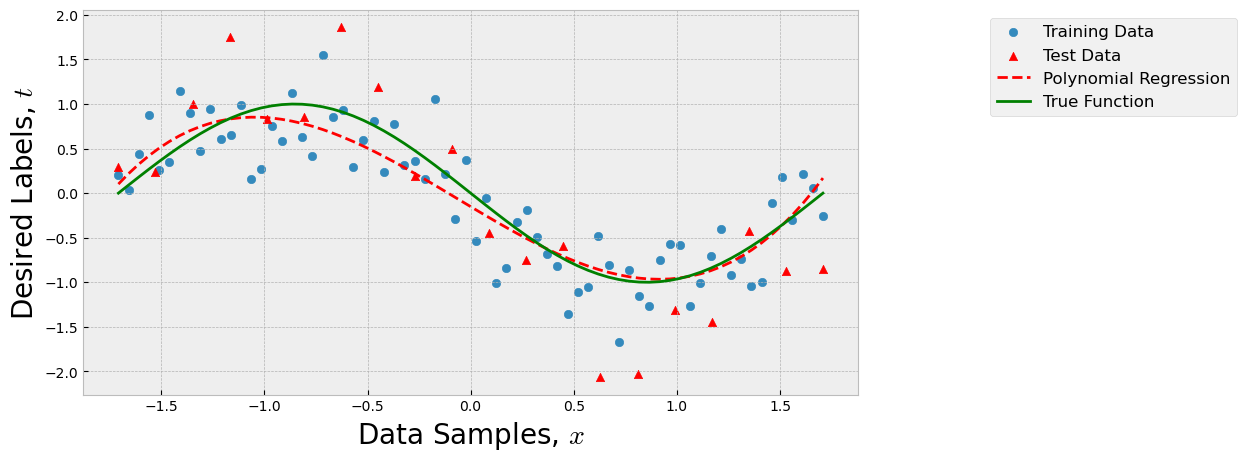

In [30]:
w, y_train = PolynomialRegression_reg(x_train, t_train, M_vals[best_m_val][0], lam_vals[best_lam_val][0])
y_test = PolynomialRegression_test(x_test, w)

fig=plt.figure(figsize=(10,5))
plt.scatter(x_train,t_train, label='Training Data')
plt.scatter(x_test,t_test, c='r', marker='^', label='Test Data')
plt.plot(x_train,y_train,'--r', label = 'Polynomial Regression')
plt.plot(x_true,t_true,'g', label = 'True Function')
plt.legend(bbox_to_anchor=(1.5, 1),fontsize=12,ncol=1)
plt.xlabel('Data Samples, $x$', fontsize=20)
plt.ylabel('Desired Labels, $t$', fontsize=20);

In [31]:
print('Training r2-score:', r2_score(t_train, y_train))
print('Test r2-score:', r2_score(t_test, y_test))

Training r2-score: 0.7802660790687206
Test r2-score: 0.6902502632554288


#### Discussion

* We select the set of hyperparameters $\{M,\lambda\}$ with the best performance score (e.g. smallest MSE or largest $r^2$).

* If the value of the hyperparameter falls at the edge of provided range of values, it is appropriate to expand the range of values for further exploration.

* Other performance measures can be used, for example, the coefficient of determination of the Q-Q plot for regression tasks, or accuracy score for classification tasks.

---

## Leave-One-Out Cross-Validation

One extreme case of cross-validation is the **leave-one-out** where given a dataset of $N$ instances, only one instance is left out as the validation set (instance) and training uses the $N − 1$ instances. We then get $N$ separate pairs by leaving out a different instance at each iteration. This is typically used in applications such as medical diagnosis, where labeled data is hard to ﬁnd. Leave-one-out **does not permit stratiﬁcation**.

---

<div class="alert alert-info">
    <b>The No Free Lunch Theorem</b> 

The No Free Lunch Theorem states that there is no single learning algorithm that in any domain always induces the most accurate learner. The usual approach is to try many and choose the one that performs the best on a separate validation set.
    
For any learning algorithm, there is a dataset where it is very accurate and another dataset where it is very poor. When we say that a learning algorithm is good, we only quantify how well its inductive bias matches the properties of the data.
</div>

---
---
---